In [2]:
# Find the first line that looks like the real CSV header
with open("hly532.csv", "r") as f:
    for i, line in enumerate(f):
        line_stripped = line.strip()

        # We want a comma-separated header, NOT the description lines like "date: - Date and Time"
        if line_stripped.startswith("date") and "," in line_stripped and ":" not in line_stripped:
            print("HEADER LINE INDEX =", i)
            print("HEADER TEXT =", line_stripped)
            break


HEADER LINE INDEX = 23
HEADER TEXT = date,ind,rain,ind,temp,ind,wetb,dewpt,vappr,rhum,msl,ind,wdsp,ind,wddir,ww,w,sun,vis,clht,clamt


In [3]:
with open("hly532.csv", "r") as f:
    for i, line in enumerate(f):
        s = line.strip()
        if s.startswith("date") and "," in s and ":" not in s:
            print("HEADER LINE INDEX =", i)
            print("HEADER TEXT =", s)
            break


HEADER LINE INDEX = 23
HEADER TEXT = date,ind,rain,ind,temp,ind,wetb,dewpt,vappr,rhum,msl,ind,wdsp,ind,wddir,ww,w,sun,vis,clht,clamt


In [4]:
import pandas as pd

header_line = 23   # <-- replace 23 with YOUR number

df = pd.read_csv(
    "hly532.csv",
    skiprows=header_line,
    sep=",",
    engine="python",
    on_bad_lines="skip"
)

df.head()


,date,ind,rain,ind.1,temp,ind.2,wetb,dewpt,vappr,rhum,...,ind.3,wdsp,ind.4,wddir,ww,w,sun,vis,clht,clamt
0,01-jan-1946 00:00,0,0.0,0,7.8,0,5.8,3.3,7.6,72,...,1,19,1,160,2,6,0.0,10000,19,8
1,01-jan-1946 01:00,0,0.6,0,7.2,0,6.0,4.4,8.4,83,...,1,20,1,160,21,6,0.0,20000,17,8
2,01-jan-1946 02:00,0,0.1,0,7.2,0,6.0,4.4,8.3,82,...,1,20,1,160,21,6,0.0,20000,19,8
3,01-jan-1946 03:00,0,0.0,0,7.1,0,5.5,3.3,7.8,77,...,1,21,1,150,2,2,0.0,20000,22,8
4,01-jan-1946 04:00,2,0.0,0,6.6,0,5.1,2.7,7.5,77,...,1,22,1,160,21,6,0.0,20000,19,8


In [5]:
df["date"] = pd.to_datetime(df["date"], format="%d-%b-%Y %H:%M", errors="coerce")

df[["date"]].head()


,date
0,1946-01-01 00:00:00
1,1946-01-01 01:00:00
2,1946-01-01 02:00:00
3,1946-01-01 03:00:00
4,1946-01-01 04:00:00


In [6]:
wind = df[["date", "wdsp"]].dropna()
wind.head()


,date,wdsp
0,1946-01-01 00:00:00,19
1,1946-01-01 01:00:00,20
2,1946-01-01 02:00:00,20
3,1946-01-01 03:00:00,21
4,1946-01-01 04:00:00,22


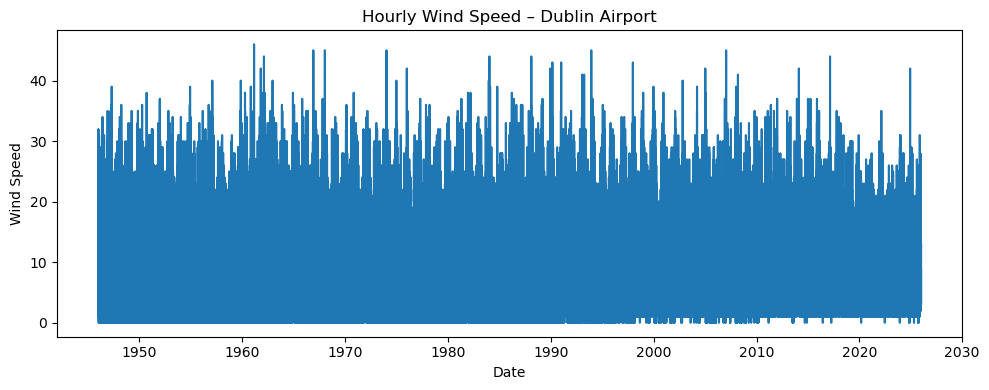

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.plot(wind["date"], wind["wdsp"])
plt.title("Hourly Wind Speed – Dublin Airport")
plt.xlabel("Date")
plt.ylabel("Wind Speed")
plt.tight_layout()
plt.show()


In [8]:
# Set date as index
wind_monthly = wind.set_index("date").resample("M").mean()

wind_monthly.head()


/var/folders/vf/d31hw_f11mj9k804v5_7zl3h0000gn/T/ipykernel_6303/3363276672.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  wind_monthly = wind.set_index("date").resample("M").mean()


,wdsp
date,
1946-01-31,12.518817
1946-02-28,13.901786
1946-03-31,11.326613
1946-04-30,10.680556
1946-05-31,11.223118


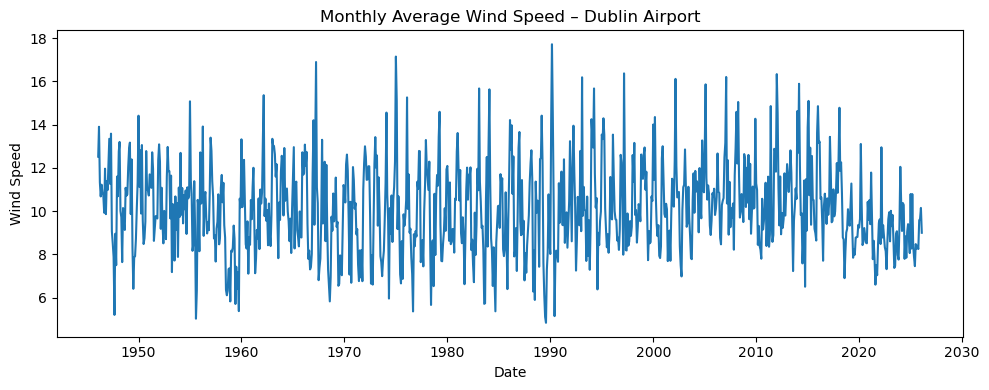

In [9]:
plt.figure(figsize=(10,4))
plt.plot(wind_monthly.index, wind_monthly["wdsp"])
plt.title("Monthly Average Wind Speed – Dublin Airport")
plt.xlabel("Date")
plt.ylabel("Wind Speed")
plt.tight_layout()
plt.show()


In [10]:
# Yearly average wind speed
wind_yearly = wind.set_index("date").resample("Y").mean()

wind_yearly.head()


/var/folders/vf/d31hw_f11mj9k804v5_7zl3h0000gn/T/ipykernel_6303/3166642328.py:2: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  wind_yearly = wind.set_index("date").resample("Y").mean()


,wdsp
date,
1946-12-31,11.259247
1947-12-31,9.951712
1948-12-31,10.539959
1949-12-31,10.264954
1950-12-31,10.699201


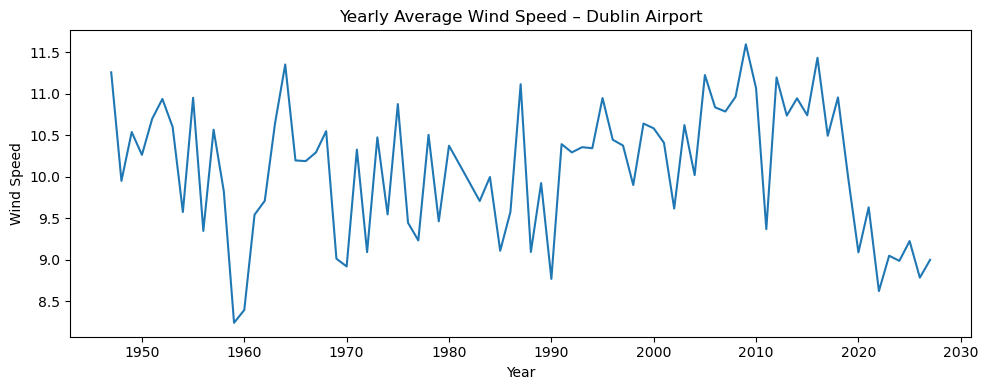

In [12]:
plt.figure(figsize=(10,4))
plt.plot(wind_yearly.index, wind_yearly["wdsp"])
plt.title("Yearly Average Wind Speed – Dublin Airport")
plt.xlabel("Year")
plt.ylabel("Wind Speed")
plt.tight_layout()
plt.show()
